<a href="https://colab.research.google.com/github/ealger22/main/blob/CSC-302-Data-Visualization/lego_setsHB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
!ls "/content/drive/My Drive/"


'Colab Notebooks'   lego_setsHB.csv   olympic_medals.csv


In [19]:
file_path = "/content/drive/My Drive/lego_setsHB.csv"


In [20]:
# Step 1: Mount Google Drive
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

# Step 2: Check file location
!ls "/content/drive/My Drive/"  # Lists files in My Drive
!ls "/content/drive/My Drive/DATA/"  # Lists files in DATA folder (if exists)

# Step 3: Update the file path based on file location
file_path = "/content/drive/My Drive/lego_setsHB.csv"  # Update if needed

# Step 4: Read the first 1000 lines from the CSV file
df = pd.read_csv(file_path, nrows=1000)

# Step 5: Initialize dictionaries for Price and Difficulty
Price = {}
Difficulty = {}

# Step 6: Populate dictionaries using prod_id as the key
for _, row in df.iterrows():
    Price[row['prod_id']] = row['list_price']
    Difficulty[row['prod_id']] = row['review_difficulty']

# Step 7: Create a formatted DataFrame for better visualization
price_difficulty_df = pd.DataFrame({
    "Product ID": list(Price.keys()),
    "Price ($)": list(Price.values()),
    "Review Difficulty": [Difficulty[pid] for pid in Price.keys()]
})

# Step 8: Display the formatted DataFrame
from IPython.display import display
display(price_difficulty_df.head(10))  # Showing first 10 rows for preview

# Step 9: Save processed data as CSV (Optional)
output_path = "/content/lego_sets_processed.csv"
price_difficulty_df.to_csv(output_path, index=False)
print(f"Processed data saved at: {output_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
'Colab Notebooks'   lego_setsHB.csv   olympic_medals.csv
ls: cannot access '/content/drive/My Drive/DATA/': No such file or directory


,Product ID,Price ($),Review Difficulty
0,75823,29.9900,Average
1,75822,19.9900,Easy
2,75821,12.9900,Easy
3,21030,113.9924,Average
4,21035,75.9924,Challenging
5,21039,60.7924,Average
6,21028,53.1924,Average
7,21029,53.1924,Average
8,21034,45.5924,Average
9,21033,45.5924,Average


Processed data saved at: /content/lego_sets_processed.csv


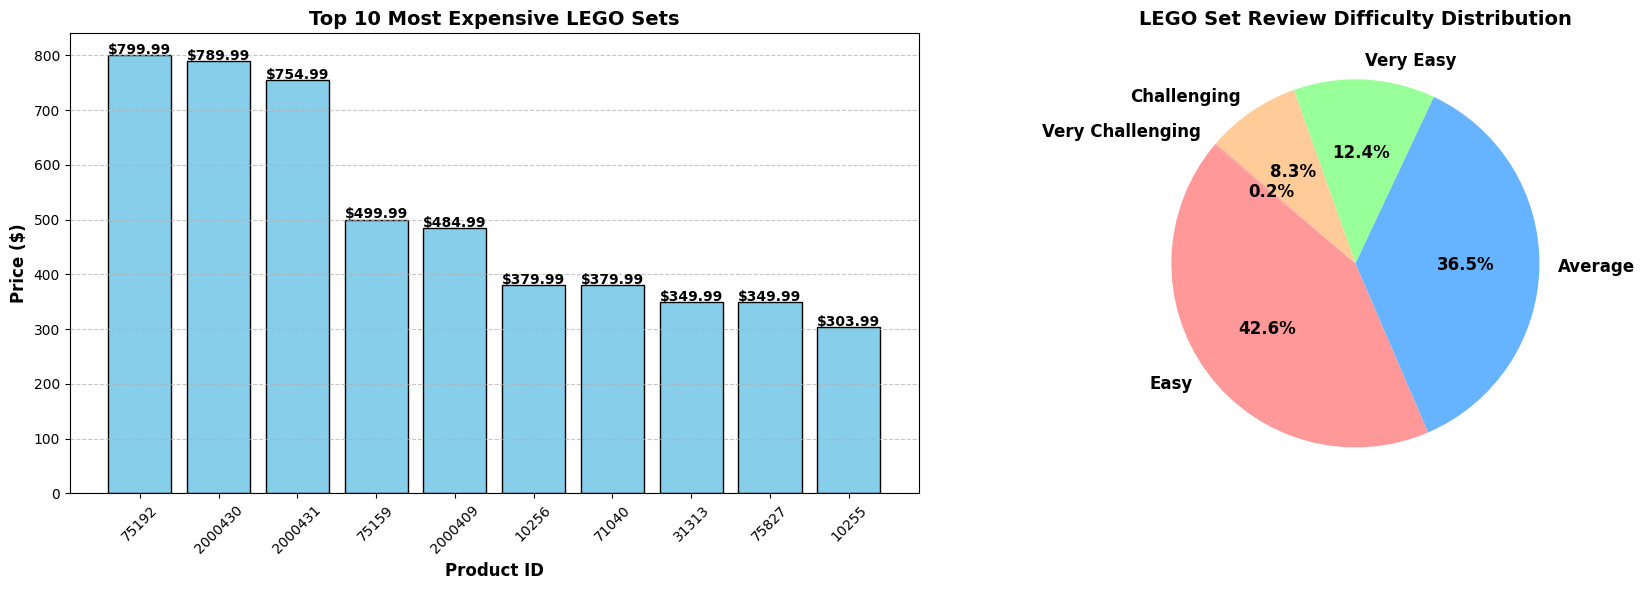

In [22]:
# Import necessary libraries
import matplotlib.pyplot as plt

# Select top 10 most expensive LEGO sets for better visualization
top_lego_sets = price_difficulty_df.sort_values(by="Price ($)", ascending=False).head(10)

# Create a figure with two subplots for a cleaner look
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ------------------- Bar Chart: Top 10 Most Expensive LEGO Sets -------------------
axes[0].bar(top_lego_sets["Product ID"].astype(str), top_lego_sets["Price ($)"], color='skyblue', edgecolor='black')

# Add data labels on top of bars
for i, price in enumerate(top_lego_sets["Price ($)"]):
    axes[0].text(i, price + 2, f"${price:.2f}", ha='center', fontsize=10, fontweight='bold')

# Formatting
axes[0].set_xlabel("Product ID", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Price ($)", fontsize=12, fontweight='bold')
axes[0].set_title("Top 10 Most Expensive LEGO Sets", fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# ------------------- Pie Chart: Review Difficulty Distribution -------------------
difficulty_counts = price_difficulty_df["Review Difficulty"].value_counts()

axes[1].pie(difficulty_counts, labels=difficulty_counts.index, autopct='%1.1f%%',
            colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'], startangle=140,
            textprops={'fontsize': 12, 'fontweight': 'bold'})

axes[1].set_title("LEGO Set Review Difficulty Distribution", fontsize=14, fontweight='bold')

# Show the combined plots
plt.tight_layout()
plt.show()
